### Binary classification using Deep Neural Networks Example: Classify movie reviews into positive" reviews and "negative" reviews, just based on the text content of the reviews. Use IMDB dataset

In [ ]:
#1. import libraries
import numpy as np
from tensorflow.keras.datasets import imdb
#Keras is like a high-level library/API, exists inside bigger TensorFlow.

from tensorflow.keras.preprocessing.sequence import pad_sequences
#movie reviews have different lengths
#So pad_sequences() makes all reviews the same size by adding zeros.
#easier to process as all reviews now of same size

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
#reviews have words. words converted to numbers. then numbers to vector
#this is done by embedding layer. vector is list of meaningful values.
#helps to recognize similiar words in easier way
#LSTM=long short term memory, helps model remember previous words in sentence.
#Bidirectional is combined with LSTM for forward and backward reading of reviews
#then both understandings are combined for better context

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#2. hyperparameters (settings you choose before training the model)
NUM_WORDS=10000 #top 10k most common words in dataset chosen, saves memory
MAX_LEN=250 #every review is made of 250 words
#if short,then padding done to add words. if big, then truncated

#load imdb dataset. 50 reviews total. 25k training, 25k testing.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)
#given in brackets because imdb load data function returns 2 groups of data
#x_train=review text as numbers, y_train=positive or negative.

print("training samples:",len(x_train))
print("testing samples:",len(x_test))
print("sample label (first review):",y_train[0], "(1=Positive, 0=Negative)")
print("sample review (first 10 words):",x_train[0][:10])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
training samples: 25000
testing samples: 25000
sample label (first review): 1 (1=Positive, 0=Negative)
sample review (first 10 words): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


In [ ]:
#3. length adjustment
#if short, pad them with zeros. if long, truncate or shorten to MAX_LEN
x_train=pad_sequences(x_train, maxlen=MAX_LEN, padding='post',truncating='post')
#post means both operations done at end of review current length

x_test=pad_sequences(x_test, maxlen=MAX_LEN,padding='post',truncating='post')
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)

x_train shape: (25000, 250)
x_test shape: (25000, 250)


In [ ]:
#4. define model
#embedding->bidirectional LStM (first 64, then 32)->dense(1, sigmoid)

model=Sequential([
    Embedding(input_dim=NUM_WORDS, output_dim=128,input_shape=(MAX_LEN,)),
    #comma needed inside bracket because shape must be a tuple in keras
    #it means 1-dimensional input with length MAX_LEN
    #input_dim=NUM_WORDS, vocabulary size = 10,000 words
    #output_dim=128, Each word becomes a vector of size 128 OR
    #128 numbers represent the word.
    #input_shape=MAX_LEN, each review has 250 words/tokens

    Bidirectional(LSTM(64, return_sequences=True)),
    #here 2 bidirectional lstm layers are used because
    #With only 1 LSTM, model learns word patterns, sentence tone,basic sentiment
    #With 2 LSTMs, model learns in stages:
    #First LSTM: understands phrases and local context ("not good","really good")
    #Second LSTM: understands overall review meaning
    #Ex: "The beginning was boring but ending was fantastic"
    #Second layer can combine information from entire review more deeply.
    #so 2 layers are used

    #BiLSTM1 Reads sentence forward and backward, learns phrase meaning,
    #local context, word relationships
    #return_sequences=True topass output for EVERY word position to next BiLSTM.

    #Imagine 2 detectives.detective 1 collects clues from every sentence.
    #detective 2 looks at all clues together and decides if 0 or 1

    Dropout(0.3),
    Bidirectional(LSTM(32)), #32 neurons and not 64 as gets processed info
    #so too much neurons not needed

    Dropout(0.3),
    Dense(1,activation='sigmoid')
    #sigmoid converts any number into a value between 0 and 1
    #helps decide if review positive or negative
])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 250, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,097 (5.42 MB)

 Trainable params: 1,420,097 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#5.compile model
model.compile(
    loss='binary_crossentropy', #Used when there are only 2 outputs/classes
    #prediction close to correct answer: small loss
    #prediction is very wrong: large loss

    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
#6. train model
early_stopping=EarlyStopping(monitor='val_loss', patience=2)
historyvariable=model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7096 - loss: 0.5625 - val_accuracy: 0.7930 - val_loss: 0.4599
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.8380 - loss: 0.3951 - val_accuracy: 0.8102 - val_loss: 0.4162
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.8942 - loss: 0.2783 - val_accuracy: 0.8592 - val_loss: 0.3411
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9079 - loss: 0.2434 - val_accuracy: 0.8398 - val_loss: 0.4036
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9390 - loss: 0.1782 - val_accuracy: 0.8430 - val_loss: 0.3953


In [ ]:
#7. testing and measure loss
loss, acc= model.evaluate(x_test, y_test, batch_size=128)
print("test accuracy:",acc)
print("test loss:",loss)

196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8511 - loss: 0.4919
test accuracy: 0.8511199951171875
test loss: 0.4919429421424866


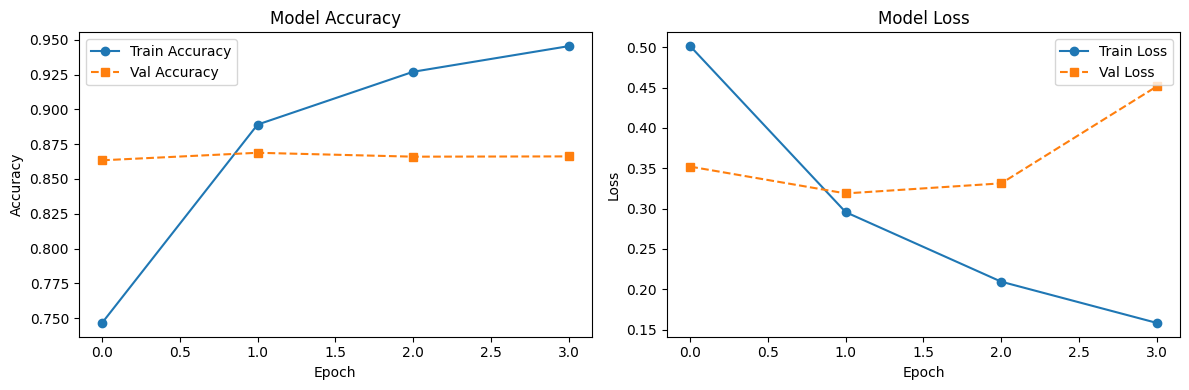

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Accuracy plot
axes[0].plot(historyvariable.history['accuracy'],

linestyle='-', marker='o', label='Train Accuracy')

axes[0].plot(historyvariable.history['val_accuracy'],

linestyle='--', marker='s', label='Val Accuracy')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
# Loss plot
axes[1].plot(historyvariable.history['loss'],

linestyle='-', marker='o', label='Train Loss')
axes[1].plot(historyvariable.history['val_loss'],

linestyle='--', marker='s', label='Val Loss')

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()